In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import math
import seaborn as sns
from scipy import stats

In [2]:
# Read csv file
df = pd.read_csv("./resource/retail_store_sales.csv")
df.set_index('Transaction ID', inplace=True, drop=False)
# Display the DataFrame
df

,Transaction ID,Customer ID,Category,Item,Price Per Unit,Quantity,Total Spent,Payment Method,Location,Transaction Date,Discount Applied
Transaction ID,,,,,,,,,,,
TXN_6867343,TXN_6867343,CUST_09,Patisserie,Item_10_PAT,18.5,10.0,185.0,Digital Wallet,Online,08-04-2024,True
TXN_3731986,TXN_3731986,CUST_22,Milk Products,Item_17_MILK,29.0,9.0,261.0,Digital Wallet,Online,23-07-2023,True
TXN_9303719,TXN_9303719,CUST_02,Butchers,Item_12_BUT,21.5,2.0,43.0,Credit Card,Online,05-10-2022,False
TXN_9458126,TXN_9458126,CUST_06,Beverages,Item_16_BEV,27.5,9.0,247.5,Credit Card,Online,07-05-2022,NaN
TXN_4575373,TXN_4575373,CUST_05,Food,Item_6_FOOD,12.5,7.0,87.5,Digital Wallet,Online,02-10-2022,False
...,...,...,...,...,...,...,...,...,...,...,...
TXN_9347481,TXN_9347481,CUST_18,Patisserie,Item_23_PAT,38.0,4.0,152.0,Credit Card,In-store,03-09-2023,NaN
TXN_4009414,TXN_4009414,CUST_03,Beverages,Item_2_BEV,6.5,9.0,58.5,Cash,Online,12-08-2022,False
TXN_5306010,TXN_5306010,CUST_11,Butchers,Item_7_BUT,14.0,10.0,140.0,Cash,Online,24-08-2024,NaN


In [3]:
# A Quick info on DataFrame Metadata ie Column names, Total Non-Nulls in each columns & DataType
df.info()

<class 'pandas.DataFrame'>
Index: 12575 entries, TXN_6867343 to TXN_2407494
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Transaction ID    12575 non-null  str    
 1   Customer ID       12575 non-null  str    
 2   Category          12575 non-null  str    
 3   Item              11362 non-null  str    
 4   Price Per Unit    11966 non-null  float64
 5   Quantity          11971 non-null  float64
 6   Total Spent       11971 non-null  float64
 7   Payment Method    12575 non-null  str    
 8   Location          12575 non-null  str    
 9   Transaction Date  12575 non-null  str    
 10  Discount Applied  8376 non-null   object 
dtypes: float64(3), object(1), str(7)
memory usage: 1.2+ MB


In [4]:
# For Numerical column Datatypes - Displaying its Statistics.
df.describe().round()

,Price Per Unit,Quantity,Total Spent
count,11966.0,11971.0,11971.0
mean,23.0,6.0,130.0
std,11.0,3.0,95.0
min,5.0,1.0,5.0
25%,14.0,3.0,51.0
50%,23.0,6.0,108.0
75%,34.0,8.0,192.0
max,41.0,10.0,410.0


In [5]:
# Displaying total number of Null's in each column.
df.isnull().sum()

Transaction ID         0
Customer ID            0
Category               0
Item                1213
Price Per Unit       609
Quantity             604
Total Spent          604
Payment Method         0
Location               0
Transaction Date       0
Discount Applied    4199
dtype: int64

In [6]:
# Displaying total number of Null's in each column in Percentages (%ages).
df.isnull().sum()/len(df) * 100

Transaction ID       0.000000
Customer ID          0.000000
Category             0.000000
Item                 9.646123
Price Per Unit       4.842942
Quantity             4.803181
Total Spent          4.803181
Payment Method       0.000000
Location             0.000000
Transaction Date     0.000000
Discount Applied    33.391650
dtype: float64

In [7]:
# Displaying total rows & columns in DataFrame.
df.shape

(12575, 11)

In [8]:
# Displaying total number of duplicate records ie rows
df[df.duplicated()].shape

(0, 11)

In [9]:
# Display the duplicate records ie rows, if any.
df[df.duplicated()]

,Transaction ID,Customer ID,Category,Item,Price Per Unit,Quantity,Total Spent,Payment Method,Location,Transaction Date,Discount Applied
Transaction ID,,,,,,,,,,,


### Note: If there are any duplicate records ie rows then that can be deleted.

In [10]:
# In this Dataset - TransactionID seems to be primary columns. So we need to check for duplicacy
# There is no duplicacy in 'Transaction ID'
df['Transaction ID'].value_counts()[df['Transaction ID'].value_counts() > 1].index.tolist()


[]

In [11]:
# Listing each customer holds how much rows/records.
df['Customer ID'].value_counts()

Customer ID
CUST_05    544
CUST_24    543
CUST_13    534
CUST_08    533
CUST_09    519
CUST_15    519
CUST_16    515
CUST_23    513
CUST_01    507
CUST_18    507
CUST_20    507
CUST_11    503
CUST_22    501
CUST_10    501
CUST_21    498
CUST_12    498
CUST_07    491
CUST_02    488
CUST_17    487
CUST_19    487
CUST_14    484
CUST_06    481
CUST_25    476
CUST_04    474
CUST_03    465
Name: count, dtype: int64

In [12]:
# Total number of unique customer ID
df['Customer ID'].nunique()

25

In [13]:
# Copying 'Item' column data to new 'Item_dup' column
df['Item_dup'] = df['Item']
df

,Transaction ID,Customer ID,Category,Item,Price Per Unit,Quantity,Total Spent,Payment Method,Location,Transaction Date,Discount Applied,Item_dup
Transaction ID,,,,,,,,,,,,
TXN_6867343,TXN_6867343,CUST_09,Patisserie,Item_10_PAT,18.5,10.0,185.0,Digital Wallet,Online,08-04-2024,True,Item_10_PAT
TXN_3731986,TXN_3731986,CUST_22,Milk Products,Item_17_MILK,29.0,9.0,261.0,Digital Wallet,Online,23-07-2023,True,Item_17_MILK
TXN_9303719,TXN_9303719,CUST_02,Butchers,Item_12_BUT,21.5,2.0,43.0,Credit Card,Online,05-10-2022,False,Item_12_BUT
TXN_9458126,TXN_9458126,CUST_06,Beverages,Item_16_BEV,27.5,9.0,247.5,Credit Card,Online,07-05-2022,NaN,Item_16_BEV
TXN_4575373,TXN_4575373,CUST_05,Food,Item_6_FOOD,12.5,7.0,87.5,Digital Wallet,Online,02-10-2022,False,Item_6_FOOD
...,...,...,...,...,...,...,...,...,...,...,...,...
TXN_9347481,TXN_9347481,CUST_18,Patisserie,Item_23_PAT,38.0,4.0,152.0,Credit Card,In-store,03-09-2023,NaN,Item_23_PAT
TXN_4009414,TXN_4009414,CUST_03,Beverages,Item_2_BEV,6.5,9.0,58.5,Cash,Online,12-08-2022,False,Item_2_BEV
TXN_5306010,TXN_5306010,CUST_11,Butchers,Item_7_BUT,14.0,10.0,140.0,Cash,Online,24-08-2024,NaN,Item_7_BUT


In [14]:
# Customer ID - Getting unique list of values
customer_id_list = df['Customer ID'].value_counts().index.tolist()
print(f"Total number of unique Customer IDs are: {len(customer_id_list)}")
print(customer_id_list)

Total number of unique Customer IDs are: 25
['CUST_05', 'CUST_24', 'CUST_13', 'CUST_08', 'CUST_09', 'CUST_15', 'CUST_16', 'CUST_23', 'CUST_01', 'CUST_18', 'CUST_20', 'CUST_11', 'CUST_22', 'CUST_10', 'CUST_21', 'CUST_12', 'CUST_07', 'CUST_02', 'CUST_17', 'CUST_19', 'CUST_14', 'CUST_06', 'CUST_25', 'CUST_04', 'CUST_03']


In [15]:
# Category - Getting unique list of values
category_list = df['Category'].value_counts().index.tolist()
print(f"Total number of unique categories are: {len(category_list)}")
print(category_list)

Total number of unique categories are: 8
['Furniture', 'Electric household essentials', 'Food', 'Milk Products', 'Butchers', 'Beverages', 'Computers and electric accessories', 'Patisserie']


In [16]:
# Method which would return index values in form of list for NaN values, if exists otherwise return an empty list.
def getNaNIndices(columnDf):
    indicesList = columnDf[columnDf.isna()].index.tolist()
    if (len(indicesList) > 0):
        # print(f"NaN values exists in list")
        return indicesList
    else:
        return []

In [17]:
# Method to return Max value from the given list
def getMaxItemNumber(itemList):
    result = list(map(lambda x: x.split("_")[1] if pd.notna(x) else '0', itemList))
    return max(list(map(int, result)))

In [18]:
# This method would return the Prefix & Postfix values for Item data.
def getPrefixPostfix(itemList):
    prefix = ""
    postfix = ""
    for item in itemList:
        if (pd.notna(item)):
            prefix = item.split("_")[0]
            postfix = item.split("_")[2]
            break
    return prefix, postfix

In [19]:
# This method would get an index values in list for NaN values. Then get max value from Item list & also Prefix & Postfix.
# Now it would start generating Item ID values by incrementing the max value by 1 & concatenating Prefix before Max value 
# & Postfix after max value separated by underscore '_'
def replace_NaN_With_Valid_ItemNumber(columnDf):
    nanIndicesList = getNaNIndices(columnDf)
    nanIndicesListLen = len(nanIndicesList)
    transactItemDict = {}
    if (nanIndicesListLen > 0):
        itemList = columnDf.to_list()
        maxNumber = getMaxItemNumber(itemList)
        prefix, postfix = getPrefixPostfix(itemList)
        for nanIndex in nanIndicesList:
            maxNumber += 1
            newItem = f"{prefix}_{maxNumber}_{postfix}"
            transactItemDict[nanIndex] = newItem
    return transactItemDict

In [20]:
# Iterating over Customer Id
for customer_id in customer_id_list:
    # For each Customer Id
    # Create a DataFrame for that Customer Id
    cust_df = df[df['Customer ID'] == customer_id]
    transactionIDsList = []
    itemsList = []
    # Iterating over Categories with a Customer Id
    for category in category_list:
        # For each Category for a given Customer Id
        # Create a DataFrame for a given Customer Id & a given Category
        cust_category_df = cust_df[cust_df['Category'] == category]
        # Get a List of Transaction Ids which is set as index for a DataFrame - a given Customer Id & a given Category
        # Get a List of Items - a given Customer Id & a given Category
        # calling replace_NaN_With_Valid_ItemNumber function - accepts Items List & Transaction IDs list & 
        # returns Dictionary/Map (newTransactItemsDict) with Transaction ID as key & new Item values as value.
        newTransactItemsDict = replace_NaN_With_Valid_ItemNumber(cust_category_df['Item'])
        # Using newTransactItemsDict replace new Item values against NaN for given Transaction IDs in main DataFrame.
        for key, value in newTransactItemsDict.items():
            df.loc[key, 'Item_dup'] = value      


In [21]:
df

,Transaction ID,Customer ID,Category,Item,Price Per Unit,Quantity,Total Spent,Payment Method,Location,Transaction Date,Discount Applied,Item_dup
Transaction ID,,,,,,,,,,,,
TXN_6867343,TXN_6867343,CUST_09,Patisserie,Item_10_PAT,18.5,10.0,185.0,Digital Wallet,Online,08-04-2024,True,Item_10_PAT
TXN_3731986,TXN_3731986,CUST_22,Milk Products,Item_17_MILK,29.0,9.0,261.0,Digital Wallet,Online,23-07-2023,True,Item_17_MILK
TXN_9303719,TXN_9303719,CUST_02,Butchers,Item_12_BUT,21.5,2.0,43.0,Credit Card,Online,05-10-2022,False,Item_12_BUT
TXN_9458126,TXN_9458126,CUST_06,Beverages,Item_16_BEV,27.5,9.0,247.5,Credit Card,Online,07-05-2022,NaN,Item_16_BEV
TXN_4575373,TXN_4575373,CUST_05,Food,Item_6_FOOD,12.5,7.0,87.5,Digital Wallet,Online,02-10-2022,False,Item_6_FOOD
...,...,...,...,...,...,...,...,...,...,...,...,...
TXN_9347481,TXN_9347481,CUST_18,Patisserie,Item_23_PAT,38.0,4.0,152.0,Credit Card,In-store,03-09-2023,NaN,Item_23_PAT
TXN_4009414,TXN_4009414,CUST_03,Beverages,Item_2_BEV,6.5,9.0,58.5,Cash,Online,12-08-2022,False,Item_2_BEV
TXN_5306010,TXN_5306010,CUST_11,Butchers,Item_7_BUT,14.0,10.0,140.0,Cash,Online,24-08-2024,NaN,Item_7_BUT


In [22]:
# Checking total number of nulls under each column in dataframe
df.isnull().sum()

Transaction ID         0
Customer ID            0
Category               0
Item                1213
Price Per Unit       609
Quantity             604
Total Spent          604
Payment Method         0
Location               0
Transaction Date       0
Discount Applied    4199
Item_dup               0
dtype: int64

In [23]:
# Checking for duplicates
df[df.duplicated()].shape

(0, 12)

In [24]:
# Calculating 'Price Per Unit' & replacing with NaN values provided we have corresponding 'Quantity' & 'Total Spent' values.
df['Price Per Unit Dup'] = df['Price Per Unit']
nanIndicesList = getNaNIndices(df['Price Per Unit Dup'])
if (len(nanIndicesList) > 0):
    for nanIndex in nanIndicesList:
        quantity = df.loc[nanIndex, 'Quantity']
        totalAmt = df.loc[nanIndex, 'Total Spent']
        if ((math.isnan(quantity) == False) & (math.isnan(totalAmt) == False)):
            df.loc[nanIndex, 'Price Per Unit Dup'] = (totalAmt/quantity)

In [25]:
# Listing out those records/rows whose 'Price Per Unit' value is NaN.
ppuNanIndicesList = getNaNIndices(df['Price Per Unit'])
len(ppuNanIndicesList)
ppuNanDf = df[df.index.isin(ppuNanIndicesList)]
ppuNanDf

,Transaction ID,Customer ID,Category,Item,Price Per Unit,Quantity,Total Spent,Payment Method,Location,Transaction Date,Discount Applied,Item_dup,Price Per Unit Dup
Transaction ID,,,,,,,,,,,,,
TXN_7482416,TXN_7482416,CUST_09,Patisserie,NaN,NaN,10.0,200.0,Credit Card,Online,30-11-2023,NaN,Item_24_PAT,20.0
TXN_5422631,TXN_5422631,CUST_09,Milk Products,NaN,NaN,8.0,52.0,Digital Wallet,In-store,12-01-2025,True,Item_25_MILK,6.5
TXN_9634894,TXN_9634894,CUST_15,Milk Products,NaN,NaN,10.0,275.0,Digital Wallet,Online,17-04-2022,NaN,Item_26_MILK,27.5
TXN_8685338,TXN_8685338,CUST_15,Milk Products,NaN,NaN,3.0,105.0,Credit Card,In-store,29-10-2023,NaN,Item_27_MILK,35.0
TXN_1543244,TXN_1543244,CUST_20,Food,NaN,NaN,8.0,196.0,Credit Card,Online,25-10-2024,True,Item_26_FOOD,24.5
...,...,...,...,...,...,...,...,...,...,...,...,...,...
TXN_5147764,TXN_5147764,CUST_01,Furniture,NaN,NaN,5.0,32.5,Credit Card,Online,06-09-2023,True,Item_31_FUR,6.5
TXN_1352194,TXN_1352194,CUST_17,Electric household essentials,NaN,NaN,4.0,86.0,Credit Card,Online,26-02-2023,NaN,Item_33_EHE,21.5
TXN_5625684,TXN_5625684,CUST_22,Computers and electric accessories,NaN,NaN,4.0,80.0,Cash,In-store,09-11-2022,True,Item_33_CEA,20.0


In [26]:
# Checking total number of nulls under each column in dataframe
df.isnull().sum()

Transaction ID           0
Customer ID              0
Category                 0
Item                  1213
Price Per Unit         609
Quantity               604
Total Spent            604
Payment Method           0
Location                 0
Transaction Date         0
Discount Applied      4199
Item_dup                 0
Price Per Unit Dup       0
dtype: int64

In [27]:
# Checking for duplicates
df[df.duplicated()].shape

(0, 13)

In [28]:
# For Numerical column Datatypes - Displaying its Statistics.
df.describe().round()

,Price Per Unit,Quantity,Total Spent,Price Per Unit Dup
count,11966.0,11971.0,11971.0,12575.0
mean,23.0,6.0,130.0,23.0
std,11.0,3.0,95.0,11.0
min,5.0,1.0,5.0,5.0
25%,14.0,3.0,51.0,14.0
50%,23.0,6.0,108.0,23.0
75%,34.0,8.0,192.0,34.0
max,41.0,10.0,410.0,41.0


In [29]:
# Calculating Median for 'Quantity' column
quantityMedian = int(df['Quantity'].median())
quantityMedian

6

In [30]:
# Filling NaN values under 'Quantity' column with its computed Median value
df.fillna({'Quantity': quantityMedian}, inplace=True)

,Transaction ID,Customer ID,Category,Item,Price Per Unit,Quantity,Total Spent,Payment Method,Location,Transaction Date,Discount Applied,Item_dup,Price Per Unit Dup
Transaction ID,,,,,,,,,,,,,
TXN_6867343,TXN_6867343,CUST_09,Patisserie,Item_10_PAT,18.5,10.0,185.0,Digital Wallet,Online,08-04-2024,True,Item_10_PAT,18.5
TXN_3731986,TXN_3731986,CUST_22,Milk Products,Item_17_MILK,29.0,9.0,261.0,Digital Wallet,Online,23-07-2023,True,Item_17_MILK,29.0
TXN_9303719,TXN_9303719,CUST_02,Butchers,Item_12_BUT,21.5,2.0,43.0,Credit Card,Online,05-10-2022,False,Item_12_BUT,21.5
TXN_9458126,TXN_9458126,CUST_06,Beverages,Item_16_BEV,27.5,9.0,247.5,Credit Card,Online,07-05-2022,NaN,Item_16_BEV,27.5
TXN_4575373,TXN_4575373,CUST_05,Food,Item_6_FOOD,12.5,7.0,87.5,Digital Wallet,Online,02-10-2022,False,Item_6_FOOD,12.5
...,...,...,...,...,...,...,...,...,...,...,...,...,...
TXN_9347481,TXN_9347481,CUST_18,Patisserie,Item_23_PAT,38.0,4.0,152.0,Credit Card,In-store,03-09-2023,NaN,Item_23_PAT,38.0
TXN_4009414,TXN_4009414,CUST_03,Beverages,Item_2_BEV,6.5,9.0,58.5,Cash,Online,12-08-2022,False,Item_2_BEV,6.5
TXN_5306010,TXN_5306010,CUST_11,Butchers,Item_7_BUT,14.0,10.0,140.0,Cash,Online,24-08-2024,NaN,Item_7_BUT,14.0


In [31]:
# Checking total number of nulls under each column in dataframe
df.isnull().sum()

Transaction ID           0
Customer ID              0
Category                 0
Item                  1213
Price Per Unit         609
Quantity                 0
Total Spent            604
Payment Method           0
Location                 0
Transaction Date         0
Discount Applied      4199
Item_dup                 0
Price Per Unit Dup       0
dtype: int64

In [32]:
# Checking for duplicates
df[df.duplicated()].shape

(0, 13)

In [33]:
# Replacing NaN values in 'Total Spent Dup' column with calculated value ie 'Price Per Unit Dup' * 'Quantity'
df['Total Spent Dup'] = df['Total Spent']
nanIndicesList = getNaNIndices(df['Total Spent Dup'])
if (len(nanIndicesList) > 0):
    for nanIndex in nanIndicesList:
        ppuDup = df.loc[nanIndex, 'Price Per Unit Dup']
        quantity = df.loc[nanIndex, 'Quantity']
        df.loc[nanIndex, 'Total Spent Dup'] = (ppuDup * quantity)

In [34]:
# Checking total number of nulls under each column in dataframe
df.isnull().sum()

Transaction ID           0
Customer ID              0
Category                 0
Item                  1213
Price Per Unit         609
Quantity                 0
Total Spent            604
Payment Method           0
Location                 0
Transaction Date         0
Discount Applied      4199
Item_dup                 0
Price Per Unit Dup       0
Total Spent Dup          0
dtype: int64

In [35]:
# Checking for duplicates
df[df.duplicated()].shape

(0, 14)

In [36]:
df

,Transaction ID,Customer ID,Category,Item,Price Per Unit,Quantity,Total Spent,Payment Method,Location,Transaction Date,Discount Applied,Item_dup,Price Per Unit Dup,Total Spent Dup
Transaction ID,,,,,,,,,,,,,,
TXN_6867343,TXN_6867343,CUST_09,Patisserie,Item_10_PAT,18.5,10.0,185.0,Digital Wallet,Online,08-04-2024,True,Item_10_PAT,18.5,185.0
TXN_3731986,TXN_3731986,CUST_22,Milk Products,Item_17_MILK,29.0,9.0,261.0,Digital Wallet,Online,23-07-2023,True,Item_17_MILK,29.0,261.0
TXN_9303719,TXN_9303719,CUST_02,Butchers,Item_12_BUT,21.5,2.0,43.0,Credit Card,Online,05-10-2022,False,Item_12_BUT,21.5,43.0
TXN_9458126,TXN_9458126,CUST_06,Beverages,Item_16_BEV,27.5,9.0,247.5,Credit Card,Online,07-05-2022,NaN,Item_16_BEV,27.5,247.5
TXN_4575373,TXN_4575373,CUST_05,Food,Item_6_FOOD,12.5,7.0,87.5,Digital Wallet,Online,02-10-2022,False,Item_6_FOOD,12.5,87.5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
TXN_9347481,TXN_9347481,CUST_18,Patisserie,Item_23_PAT,38.0,4.0,152.0,Credit Card,In-store,03-09-2023,NaN,Item_23_PAT,38.0,152.0
TXN_4009414,TXN_4009414,CUST_03,Beverages,Item_2_BEV,6.5,9.0,58.5,Cash,Online,12-08-2022,False,Item_2_BEV,6.5,58.5
TXN_5306010,TXN_5306010,CUST_11,Butchers,Item_7_BUT,14.0,10.0,140.0,Cash,Online,24-08-2024,NaN,Item_7_BUT,14.0,140.0


In [37]:
# Calculating Mode for 'Discount Applied' column
discountAppliedMode = df['Discount Applied'].mode()[0]
discountAppliedMode

True

In [38]:
# Replacing NaN values under 'Discount Applied' column with its Mode value.
df.fillna({'Discount Applied': discountAppliedMode}, inplace=True)

,Transaction ID,Customer ID,Category,Item,Price Per Unit,Quantity,Total Spent,Payment Method,Location,Transaction Date,Discount Applied,Item_dup,Price Per Unit Dup,Total Spent Dup
Transaction ID,,,,,,,,,,,,,,
TXN_6867343,TXN_6867343,CUST_09,Patisserie,Item_10_PAT,18.5,10.0,185.0,Digital Wallet,Online,08-04-2024,True,Item_10_PAT,18.5,185.0
TXN_3731986,TXN_3731986,CUST_22,Milk Products,Item_17_MILK,29.0,9.0,261.0,Digital Wallet,Online,23-07-2023,True,Item_17_MILK,29.0,261.0
TXN_9303719,TXN_9303719,CUST_02,Butchers,Item_12_BUT,21.5,2.0,43.0,Credit Card,Online,05-10-2022,False,Item_12_BUT,21.5,43.0
TXN_9458126,TXN_9458126,CUST_06,Beverages,Item_16_BEV,27.5,9.0,247.5,Credit Card,Online,07-05-2022,True,Item_16_BEV,27.5,247.5
TXN_4575373,TXN_4575373,CUST_05,Food,Item_6_FOOD,12.5,7.0,87.5,Digital Wallet,Online,02-10-2022,False,Item_6_FOOD,12.5,87.5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
TXN_9347481,TXN_9347481,CUST_18,Patisserie,Item_23_PAT,38.0,4.0,152.0,Credit Card,In-store,03-09-2023,True,Item_23_PAT,38.0,152.0
TXN_4009414,TXN_4009414,CUST_03,Beverages,Item_2_BEV,6.5,9.0,58.5,Cash,Online,12-08-2022,False,Item_2_BEV,6.5,58.5
TXN_5306010,TXN_5306010,CUST_11,Butchers,Item_7_BUT,14.0,10.0,140.0,Cash,Online,24-08-2024,True,Item_7_BUT,14.0,140.0


In [39]:
# Checking total number of nulls under each column in dataframe
df.isnull().sum()

Transaction ID           0
Customer ID              0
Category                 0
Item                  1213
Price Per Unit         609
Quantity                 0
Total Spent            604
Payment Method           0
Location                 0
Transaction Date         0
Discount Applied         0
Item_dup                 0
Price Per Unit Dup       0
Total Spent Dup          0
dtype: int64

In [40]:
# Checking for duplicates
df[df.duplicated()].shape

(0, 14)

In [41]:

# Copying values from *_dup column to its corresponding original columns after remove NaN values.
df['Item'] = df['Item_dup']
df['Price Per Unit'] = df['Price Per Unit Dup']
df['Total Spent'] = df['Total Spent Dup']

In [42]:
# Now dropping *_dup columns
df = df.drop(columns=['Item_dup', 'Price Per Unit Dup', 'Total Spent Dup'])
df

,Transaction ID,Customer ID,Category,Item,Price Per Unit,Quantity,Total Spent,Payment Method,Location,Transaction Date,Discount Applied
Transaction ID,,,,,,,,,,,
TXN_6867343,TXN_6867343,CUST_09,Patisserie,Item_10_PAT,18.5,10.0,185.0,Digital Wallet,Online,08-04-2024,True
TXN_3731986,TXN_3731986,CUST_22,Milk Products,Item_17_MILK,29.0,9.0,261.0,Digital Wallet,Online,23-07-2023,True
TXN_9303719,TXN_9303719,CUST_02,Butchers,Item_12_BUT,21.5,2.0,43.0,Credit Card,Online,05-10-2022,False
TXN_9458126,TXN_9458126,CUST_06,Beverages,Item_16_BEV,27.5,9.0,247.5,Credit Card,Online,07-05-2022,True
TXN_4575373,TXN_4575373,CUST_05,Food,Item_6_FOOD,12.5,7.0,87.5,Digital Wallet,Online,02-10-2022,False
...,...,...,...,...,...,...,...,...,...,...,...
TXN_9347481,TXN_9347481,CUST_18,Patisserie,Item_23_PAT,38.0,4.0,152.0,Credit Card,In-store,03-09-2023,True
TXN_4009414,TXN_4009414,CUST_03,Beverages,Item_2_BEV,6.5,9.0,58.5,Cash,Online,12-08-2022,False
TXN_5306010,TXN_5306010,CUST_11,Butchers,Item_7_BUT,14.0,10.0,140.0,Cash,Online,24-08-2024,True


In [43]:
# Checking total number of nulls under each column in dataframe
df.isnull().sum()

Transaction ID      0
Customer ID         0
Category            0
Item                0
Price Per Unit      0
Quantity            0
Total Spent         0
Payment Method      0
Location            0
Transaction Date    0
Discount Applied    0
dtype: int64

In [44]:
# Checking for duplicates
df[df.duplicated()].shape

(0, 11)

In [45]:
# Checking if 'Transaction ID' column contains unique value.
df['Transaction ID'].value_counts()

Transaction ID
TXN_6867343    1
TXN_3731986    1
TXN_9303719    1
TXN_9458126    1
TXN_4575373    1
              ..
TXN_9347481    1
TXN_4009414    1
TXN_5306010    1
TXN_5167298    1
TXN_2407494    1
Name: count, Length: 12575, dtype: int64

In [46]:
df

,Transaction ID,Customer ID,Category,Item,Price Per Unit,Quantity,Total Spent,Payment Method,Location,Transaction Date,Discount Applied
Transaction ID,,,,,,,,,,,
TXN_6867343,TXN_6867343,CUST_09,Patisserie,Item_10_PAT,18.5,10.0,185.0,Digital Wallet,Online,08-04-2024,True
TXN_3731986,TXN_3731986,CUST_22,Milk Products,Item_17_MILK,29.0,9.0,261.0,Digital Wallet,Online,23-07-2023,True
TXN_9303719,TXN_9303719,CUST_02,Butchers,Item_12_BUT,21.5,2.0,43.0,Credit Card,Online,05-10-2022,False
TXN_9458126,TXN_9458126,CUST_06,Beverages,Item_16_BEV,27.5,9.0,247.5,Credit Card,Online,07-05-2022,True
TXN_4575373,TXN_4575373,CUST_05,Food,Item_6_FOOD,12.5,7.0,87.5,Digital Wallet,Online,02-10-2022,False
...,...,...,...,...,...,...,...,...,...,...,...
TXN_9347481,TXN_9347481,CUST_18,Patisserie,Item_23_PAT,38.0,4.0,152.0,Credit Card,In-store,03-09-2023,True
TXN_4009414,TXN_4009414,CUST_03,Beverages,Item_2_BEV,6.5,9.0,58.5,Cash,Online,12-08-2022,False
TXN_5306010,TXN_5306010,CUST_11,Butchers,Item_7_BUT,14.0,10.0,140.0,Cash,Online,24-08-2024,True


In [47]:
# Describing columns in Dataframe
df.info()

<class 'pandas.DataFrame'>
Index: 12575 entries, TXN_6867343 to TXN_2407494
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Transaction ID    12575 non-null  str    
 1   Customer ID       12575 non-null  str    
 2   Category          12575 non-null  str    
 3   Item              12575 non-null  str    
 4   Price Per Unit    12575 non-null  float64
 5   Quantity          12575 non-null  float64
 6   Total Spent       12575 non-null  float64
 7   Payment Method    12575 non-null  str    
 8   Location          12575 non-null  str    
 9   Transaction Date  12575 non-null  str    
 10  Discount Applied  12575 non-null  object 
dtypes: float64(3), object(1), str(7)
memory usage: 1.4+ MB


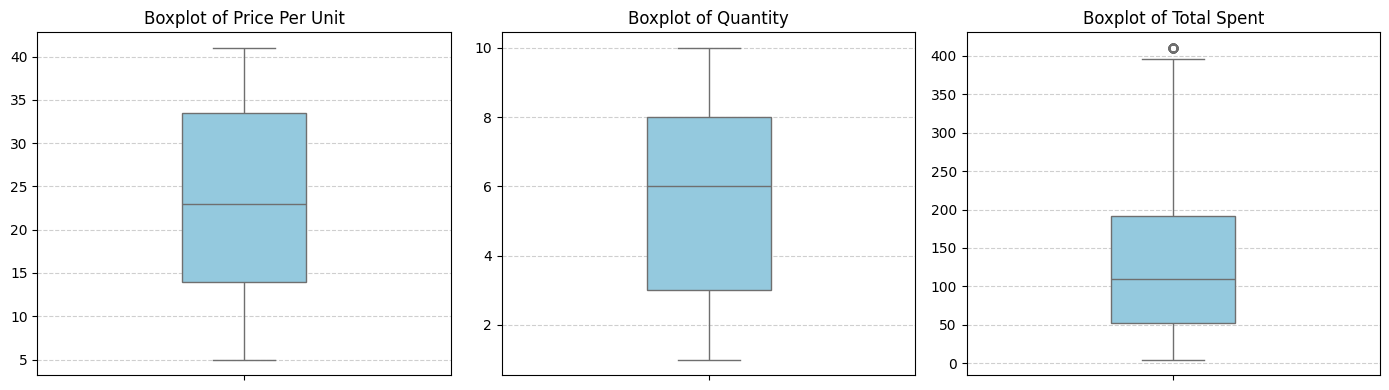

In [48]:
# Print box plots for outliers.
cols = ['Price Per Unit', 'Quantity', 'Total Spent']
		
plt.figure(figsize=(14, 4))
		
for i, col in enumerate(cols, 1):
	plt.subplot(1, 3, i)
	sns.boxplot(data=df[col], color='skyblue', width=0.3)
	plt.title(f'Boxplot of {col}', fontsize=12)
	plt.ylabel('')
	plt.grid(axis='y', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()


In [49]:
# Calculating Z-score for columns 'Price Per Unit', 'Quantity' & 'Total Spent'.
z_scores = np.abs(stats.zscore(df[ ['Price Per Unit', 'Quantity', 'Total Spent'] ])) # Note: If the Z-score is greater than 3 standard deviation then they are outliers.
z_scores


array([[0.45303016, 1.59185443, 0.58552764],
       [0.52386849, 1.23343779, 1.39769349],
       [0.17391626, 1.27547871, 0.93194013],
       ...,
       [0.871701  , 1.59185443, 0.10463997],
       [0.871701  , 0.15818786, 0.49379802],
       [0.5925871 , 0.91706206, 0.84644898]], shape=(12575, 3))

In [50]:
# Create a new Dataframe by excluding an outliers. Exclusion rule is any Z-score value greater than 3 should be excluded or removed.
df_clean = df[~(z_scores > 3).any(axis=1)]
df_clean

,Transaction ID,Customer ID,Category,Item,Price Per Unit,Quantity,Total Spent,Payment Method,Location,Transaction Date,Discount Applied
Transaction ID,,,,,,,,,,,
TXN_6867343,TXN_6867343,CUST_09,Patisserie,Item_10_PAT,18.5,10.0,185.0,Digital Wallet,Online,08-04-2024,True
TXN_3731986,TXN_3731986,CUST_22,Milk Products,Item_17_MILK,29.0,9.0,261.0,Digital Wallet,Online,23-07-2023,True
TXN_9303719,TXN_9303719,CUST_02,Butchers,Item_12_BUT,21.5,2.0,43.0,Credit Card,Online,05-10-2022,False
TXN_9458126,TXN_9458126,CUST_06,Beverages,Item_16_BEV,27.5,9.0,247.5,Credit Card,Online,07-05-2022,True
TXN_4575373,TXN_4575373,CUST_05,Food,Item_6_FOOD,12.5,7.0,87.5,Digital Wallet,Online,02-10-2022,False
...,...,...,...,...,...,...,...,...,...,...,...
TXN_9347481,TXN_9347481,CUST_18,Patisserie,Item_23_PAT,38.0,4.0,152.0,Credit Card,In-store,03-09-2023,True
TXN_4009414,TXN_4009414,CUST_03,Beverages,Item_2_BEV,6.5,9.0,58.5,Cash,Online,12-08-2022,False
TXN_5306010,TXN_5306010,CUST_11,Butchers,Item_7_BUT,14.0,10.0,140.0,Cash,Online,24-08-2024,True


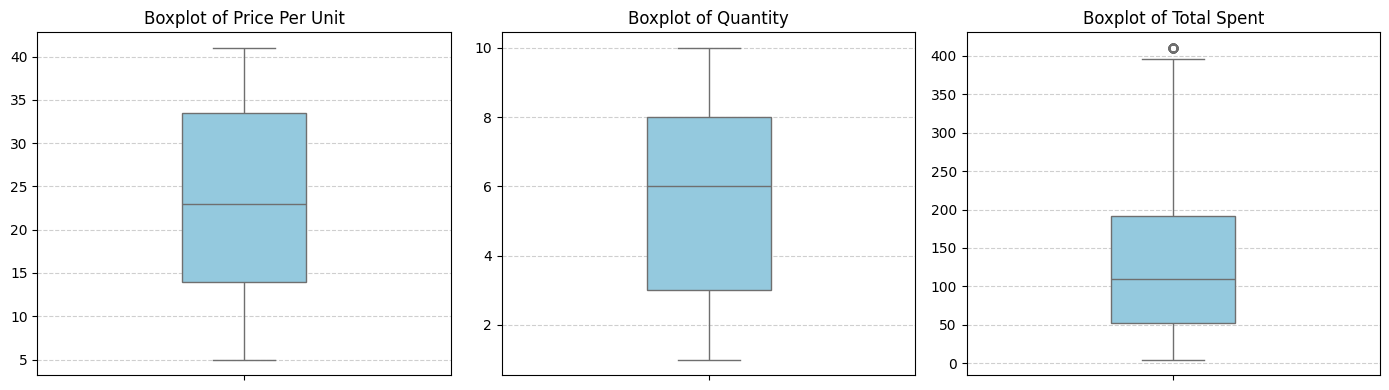

In [51]:
# Print box plots after removing outliers.
cols = ['Price Per Unit', 'Quantity', 'Total Spent']
		
plt.figure(figsize=(14, 4))
		
for i, col in enumerate(cols, 1):
	plt.subplot(1, 3, i)
	sns.boxplot(data=df_clean[col], color='skyblue', width=0.3)
	plt.title(f'Boxplot of {col}', fontsize=12)
	plt.ylabel('')
	plt.grid(axis='y', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

In [56]:
df_clean

,Transaction ID,Customer ID,Category,Item,Price Per Unit,Quantity,Total Spent,Payment Method,Location,Transaction Date,Discount Applied
Transaction ID,,,,,,,,,,,
TXN_6867343,TXN_6867343,CUST_09,Patisserie,Item_10_PAT,18.5,10.0,185.0,Digital Wallet,Online,08-04-2024,True
TXN_3731986,TXN_3731986,CUST_22,Milk Products,Item_17_MILK,29.0,9.0,261.0,Digital Wallet,Online,23-07-2023,True
TXN_9303719,TXN_9303719,CUST_02,Butchers,Item_12_BUT,21.5,2.0,43.0,Credit Card,Online,05-10-2022,False
TXN_9458126,TXN_9458126,CUST_06,Beverages,Item_16_BEV,27.5,9.0,247.5,Credit Card,Online,07-05-2022,True
TXN_4575373,TXN_4575373,CUST_05,Food,Item_6_FOOD,12.5,7.0,87.5,Digital Wallet,Online,02-10-2022,False
...,...,...,...,...,...,...,...,...,...,...,...
TXN_9347481,TXN_9347481,CUST_18,Patisserie,Item_23_PAT,38.0,4.0,152.0,Credit Card,In-store,03-09-2023,True
TXN_4009414,TXN_4009414,CUST_03,Beverages,Item_2_BEV,6.5,9.0,58.5,Cash,Online,12-08-2022,False
TXN_5306010,TXN_5306010,CUST_11,Butchers,Item_7_BUT,14.0,10.0,140.0,Cash,Online,24-08-2024,True


In [ ]:
#df_clean = df_clean.drop(columns=['Item_dup', 'Price Per Unit Dup', 'Total Spent Dup'])
#df_clean

In [ ]:
# Writing modified csv after cleansing process
df_clean.to_csv("./resource/retail_store_sales_clean.csv", index=False)

In [55]:
# Reading & displaying modified csv
df_modified = pd.read_csv("./resource/retail_store_sales_clean.csv")
df_modified

,Transaction ID,Transaction ID.1,Customer ID,Category,Item,Price Per Unit,Quantity,Total Spent,Payment Method,Location,Transaction Date,Discount Applied
0,TXN_6867343,TXN_6867343,CUST_09,Patisserie,Item_10_PAT,18.5,10.0,185.0,Digital Wallet,Online,08-04-2024,True
1,TXN_3731986,TXN_3731986,CUST_22,Milk Products,Item_17_MILK,29.0,9.0,261.0,Digital Wallet,Online,23-07-2023,True
2,TXN_9303719,TXN_9303719,CUST_02,Butchers,Item_12_BUT,21.5,2.0,43.0,Credit Card,Online,05-10-2022,False
3,TXN_9458126,TXN_9458126,CUST_06,Beverages,Item_16_BEV,27.5,9.0,247.5,Credit Card,Online,07-05-2022,True
4,TXN_4575373,TXN_4575373,CUST_05,Food,Item_6_FOOD,12.5,7.0,87.5,Digital Wallet,Online,02-10-2022,False
...,...,...,...,...,...,...,...,...,...,...,...,...
12570,TXN_9347481,TXN_9347481,CUST_18,Patisserie,Item_23_PAT,38.0,4.0,152.0,Credit Card,In-store,03-09-2023,True
12571,TXN_4009414,TXN_4009414,CUST_03,Beverages,Item_2_BEV,6.5,9.0,58.5,Cash,Online,12-08-2022,False
12572,TXN_5306010,TXN_5306010,CUST_11,Butchers,Item_7_BUT,14.0,10.0,140.0,Cash,Online,24-08-2024,True
12573,TXN_5167298,TXN_5167298,CUST_04,Furniture,Item_7_FUR,14.0,6.0,84.0,Cash,Online,30-12-2023,True
